In [2]:
#STEP 1: Imports and Setup
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import your custom modules
from ml_common import load_clean_data, DEFAULT_DATASET
from baseline_models import run_logistic_regression, run_linear_regression, build_feature_table
import random_forest_model
import svm_model
import xgboost_model
import high_performance_genre_pipeline as hp_pipeline

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Dataset loaded: spotify_remapped.csv
Total tracks: 114000


C:\Users\vidhi\AppData\Local\Temp\ipykernel_51048\668952793.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y="track_genre", order=data["track_genre"].value_counts().index, palette="viridis")


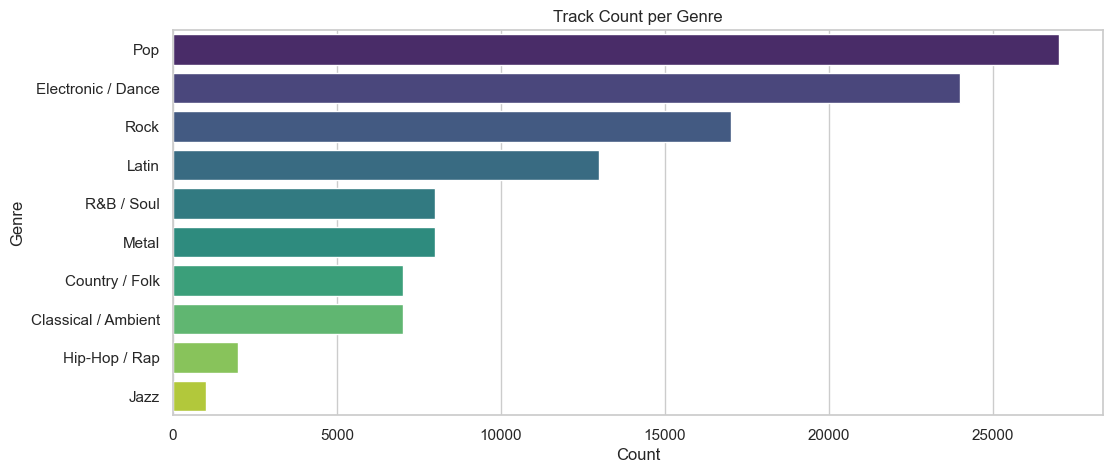

In [3]:
# STEP 2: Load and Verify Data
dataset_path = "spotify_remapped.csv" # Or spotify_balanced.csv
data = load_clean_data(dataset_path)

print(f"Dataset loaded: {dataset_path}")
print(f"Total tracks: {len(data)}")

# Visualize the class balance
plt.figure(figsize=(12, 5))
sns.countplot(data=data, y="track_genre", order=data["track_genre"].value_counts().index, palette="viridis")
plt.title("Track Count per Genre")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [4]:
# STEP 3: Run Baseline Models
print("--- Running Baseline Models ---")
# Build the specific feature table expected by your baseline script
df_features = build_feature_table(pd.read_csv(dataset_path))

run_logistic_regression(df_features, test_size=0.2, random_state=42)
run_linear_regression(df_features, test_size=0.2, random_state=42)

--- Running Baseline Models ---

=== Logistic Regression (Genre Classification) ===
Train samples: 91200 | Test samples: 22800
Accuracy: 0.3206

Classification report:
                     precision    recall  f1-score   support

Classical / Ambient     0.4986    0.6350    0.5586      1400
     Country / Folk     0.1846    0.2757    0.2211      1400
 Electronic / Dance     0.6307    0.4383    0.5172      4800
      Hip-Hop / Rap     0.0862    0.6675    0.1526       400
               Jazz     0.0605    0.6200    0.1103       200
              Latin     0.3657    0.3719    0.3688      2600
              Metal     0.3695    0.7494    0.4949      1600
                Pop     0.4754    0.0715    0.1243      5400
         R&B / Soul     0.1247    0.0587    0.0799      1600
               Rock     0.2993    0.2629    0.2799      3400

           accuracy                         0.3206     22800
          macro avg     0.3095    0.4151    0.2908     22800
       weighted avg     0.4104    0.3

In [5]:
# STEP 4: Run Random Forest and SVM
# Note: You may want to use spotify_balanced.csv for SVM if the full dataset takes too long to train
print("--- Running Random Forest ---")
# You can call the main() functions directly by overriding the sys.argv if needed, 
# but for simplicity, you can also just run the scripts via shell commands in Jupyter:
!python random_forest_model.py --data spotify_remapped.csv

print("\n--- Running SVM-RBF ---")
!python svm_model.py --data spotify_balanced.csv

--- Running Random Forest ---
=== Random Forest (Genre Classification) ===
Train: 91200 | Test: 22800
Accuracy: 0.5612
                     precision    recall  f1-score   support

Classical / Ambient     0.6337    0.6907    0.6610      1400
     Country / Folk     0.6303    0.5614    0.5939      1400
 Electronic / Dance     0.6717    0.6985    0.6848      4800
      Hip-Hop / Rap     0.3315    0.2950    0.3122       400
               Jazz     0.4978    0.5650    0.5293       200
              Latin     0.6093    0.5788    0.5937      2600
              Metal     0.5995    0.6175    0.6084      1600
                Pop     0.4944    0.5963    0.5406      5400
         R&B / Soul     0.3362    0.1963    0.2478      1600
               Rock     0.4957    0.4209    0.4552      3400

           accuracy                         0.5612     22800
          macro avg     0.5300    0.5220    0.5227     22800
       weighted avg     0.5554    0.5612    0.5551     22800

=== Random Forest (Popul

In [6]:
# STEP 5: Run XGBoost (Classification & Regression)
print("--- Running XGBoost ---")
!python xgboost_model.py --data spotify_remapped.csv

--- Running XGBoost ---
=== XGBoost (Genre Classification) ===
Train: 91200 | Test: 22800
Accuracy: 0.4914
                     precision    recall  f1-score   support

Classical / Ambient     0.5489    0.7543    0.6354      1400
     Country / Folk     0.3408    0.6836    0.4548      1400
 Electronic / Dance     0.7022    0.6112    0.6536      4800
      Hip-Hop / Rap     0.1603    0.5900    0.2521       400
               Jazz     0.3133    0.6000    0.4117       200
              Latin     0.5348    0.5673    0.5506      2600
              Metal     0.5105    0.7425    0.6050      1600
                Pop     0.6062    0.2902    0.3925      5400
         R&B / Soul     0.2766    0.2894    0.2828      1600
               Rock     0.4485    0.3550    0.3963      3400

           accuracy                         0.4914     22800
          macro avg     0.4442    0.5483    0.4635     22800
       weighted avg     0.5347    0.4914    0.4897     22800



=== XGBoost (Popularity Regression

Train: 91200 | Test: 22800 | Classes: 10

=== XGBoost Genre Classifier ===
Top-1 Accuracy: 0.5105
Top-3 Accuracy: 0.8363

Classification report:
                     precision    recall  f1-score   support

Classical / Ambient     0.5635    0.7514    0.6440      1400
     Country / Folk     0.3759    0.6893    0.4865      1400
 Electronic / Dance     0.6878    0.6383    0.6621      4800
      Hip-Hop / Rap     0.1927    0.4750    0.2742       400
               Jazz     0.4270    0.5850    0.4937       200
              Latin     0.5401    0.5908    0.5643      2600
              Metal     0.5247    0.7113    0.6039      1600
                Pop     0.5908    0.3356    0.4280      5400
         R&B / Soul     0.2746    0.2825    0.2785      1600
               Rock     0.4492    0.3865    0.4155      3400

           accuracy                         0.5105     22800
          macro avg     0.4626    0.5446    0.4851     22800
       weighted avg     0.5342    0.5105    0.5076     22800

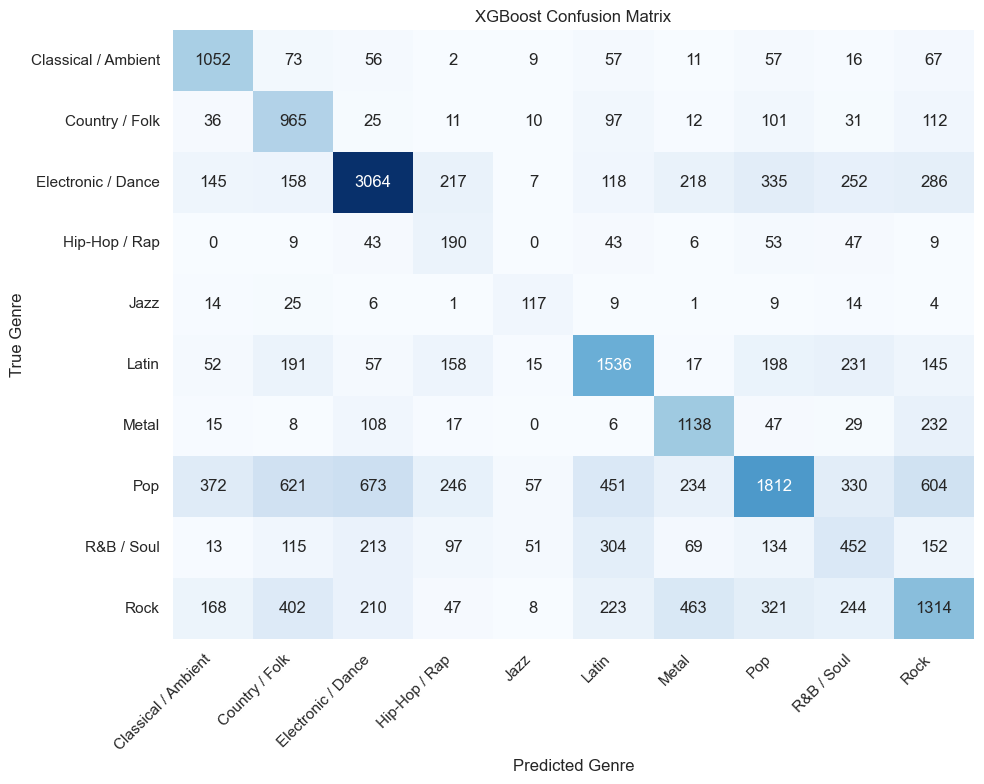

C:\Users\vidhi\AppData\Local\Temp\ipykernel_51048\91611322.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="importance", y="feature", palette="mako")


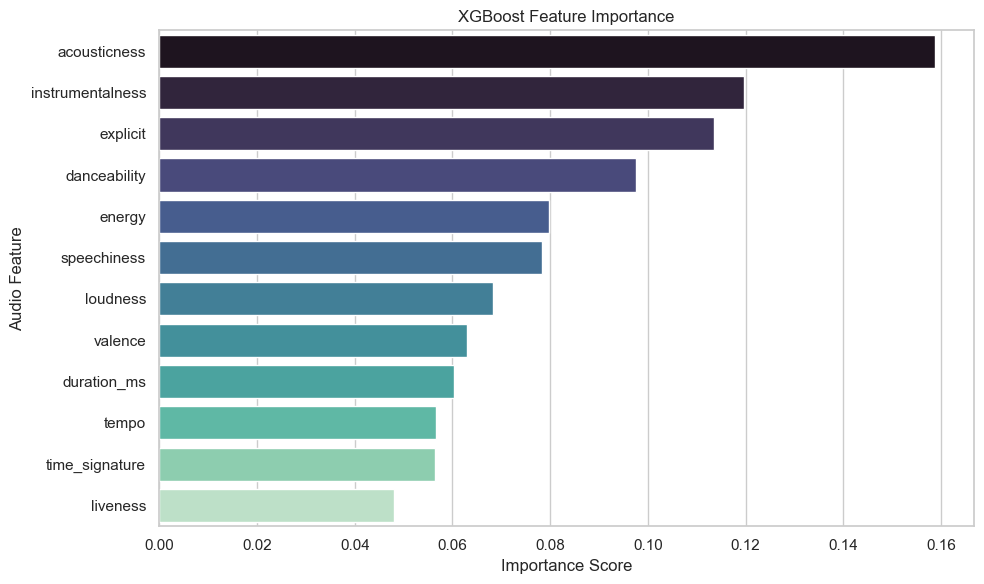

In [7]:
# STEP 6: High-Performance Pipeline and Visualizations
import json
from pathlib import Path

# Run the pipeline
!python high_performance_genre_pipeline.py --data spotify_remapped.csv

# Load the saved artifacts
out_dir = Path("model_outputs/high_performance_xgb")
cm_df = pd.read_csv(out_dir / "confusion_matrix.csv", index_col=0)
feat_imp = pd.read_csv(out_dir / "feature_importance.csv")

# 1. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("XGBoost Confusion Matrix")
plt.ylabel("True Genre")
plt.xlabel("Predicted Genre")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="importance", y="feature", palette="mako")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()

C:\Users\vidhi\AppData\Local\Temp\ipykernel_51048\1560896050.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=accuracies, y=models, palette="magma")


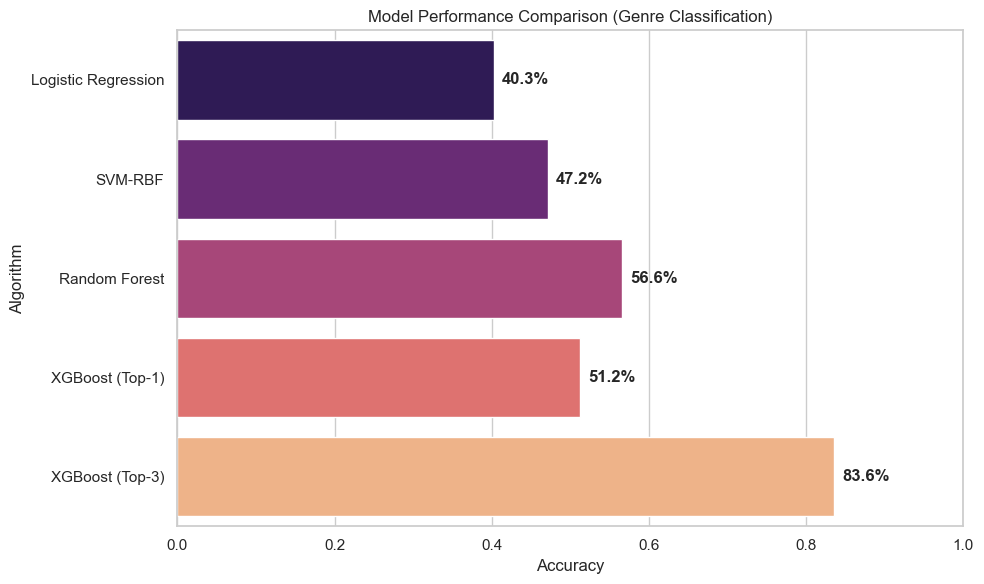

In [8]:
# Performance Comparison Chart (for the models)
import numpy as np

# Data gathered from your previous notebook cell outputs
models = ['Logistic Regression', 'SVM-RBF', 'Random Forest', 'XGBoost (Top-1)', 'XGBoost (Top-3)']
accuracies = [0.4027, 0.4720, 0.5661, 0.5122, 0.8357]

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=accuracies, y=models, palette="magma")

for i, bar in enumerate(bars.patches):
    plt.text(bar.get_width() + 0.01, 
             bar.get_y() + bar.get_height()/2, 
             f'{accuracies[i]*100:.1f}%', 
             va='center', fontweight='bold')

plt.title("Model Performance Comparison (Genre Classification)")
plt.xlabel("Accuracy")
plt.ylabel("Algorithm")
plt.xlim(0, 1.0) # Set x-axis from 0 to 100%
plt.tight_layout()
plt.show()

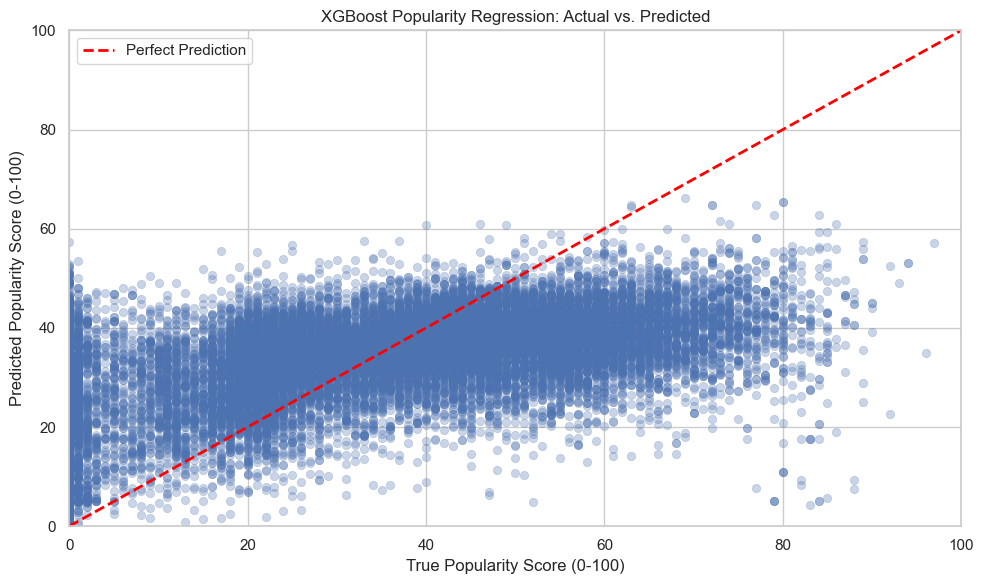

In [9]:
#Actual vs. Predicted Popularity Scatter Plot
from ml_common import split_regression
from xgboost import XGBRegressor

x_train_r, x_test_r, y_train_r, y_test_r = split_regression(
    data, test_size=0.2, random_state=42
)

reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=700,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)
reg.fit(x_train_r, y_train_r)
preds_r = reg.predict(x_test_r)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_r, y=preds_r, alpha=0.3, color="#4C72B0", edgecolor=None)

plt.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("XGBoost Popularity Regression: Actual vs. Predicted")
plt.xlabel("True Popularity Score (0-100)")
plt.ylabel("Predicted Popularity Score (0-100)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()